# 0. Import and set up

In [ ]:
import os
import time
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map  # parallel + progress

import shutil
from pathlib import Path
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt

# Force edge labels and ticks to automatically shift color based on background
# plt.rcParams.update({
#     "figure.facecolor": (0, 0, 0, 0),  # Alpha = 0 (Transparent background)
#     "axes.facecolor": (0, 0, 0, 0),    # Alpha = 0 (Transparent plot area)
#     "savefig.facecolor": (0, 0, 0, 0),
#     "text.color": "white",              # Auto-detects text contrast
#     "axes.edgecolor": "gray",          # Neutral borders that work on both
#     "xtick.color": "gray",
#     "ytick.color": "gray",
#     "axes.labelcolor": "gray"          # Muted gray labels look great on black or white
# })

import sys
sys.path.append("../scripts")
DATA_PATH = "../data/"

from helper_functions import compute_hash, show_duplicates, show_random_samples
%load_ext autoreload
%autoreload 2




## 0.1 Datasets configuration



Before proceeding, please verify that you have the necessary datasets in your working directory.
If starting from scratch, download these datasets:

- Kaggle - hasnainjaved/melanoma-skin-cancer-dataset: https://www.kaggle.com/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images
- ISIC 2016 - https://challenge.isic-archive.com/data/#2016
- ISIC 2020 - https://challenge.isic-archive.com/data/#2020 

Download and set the path below accordingly.
If you download the combined dataset, move to section 0.3

### 0.1.1 Download and combine data

In [ ]:
# If datasets downloaded from Kaggle, set the path to the downloaded datasets here. 
kaggle_10000path = os.path.join(DATA_PATH, "kaggle/")
ISIC2016_image_dir = os.path.join(DATA_PATH,"ISIC2016/images/")
ISIC2016_label_path = os.path.join(DATA_PATH,"ISIC2016/ISIC2016_GroundTruth.csv")
ISIC2020_image_dir = os.path.join(DATA_PATH,"ISIC2020/images/")
ISIC2020_label_path = os.path.join(DATA_PATH,"ISIC2020/ISIC2020_GroundTruth.csv")

In [ ]:
# CONFIGURATION & HELPER FUNCTIONS
from helper_functions import collect_kaggle_images
import shutil 
output_dir = os.path.join(DATA_PATH, "all_images")
output_csv = os.path.join(DATA_PATH, "combined_labels.csv")
os.makedirs(output_dir, exist_ok=True)

# LOAD DATASETS

# --- KAGGLE ---
kaggle_df = pd.concat([
    collect_kaggle_images(os.path.join(kaggle_10000path, "train"), "benign"),
    collect_kaggle_images(os.path.join(kaggle_10000path, "train"), "malignant"),
    collect_kaggle_images(os.path.join(kaggle_10000path, "test"), "benign"),
    collect_kaggle_images(os.path.join(kaggle_10000path, "test"), "malignant")
], ignore_index=True)

# --- ISIC 2016 ---
isic16_df = pd.read_csv(ISIC2016_label_path, names=["image_id", "label"])
isic16_df["file_path"] = isic16_df["image_id"].apply(lambda x: os.path.join(ISIC2016_image_dir, f"{x}.jpg"))
isic16_df = isic16_df[isic16_df["file_path"].apply(os.path.exists)]

# --- ISIC 2020 ---
isic20_df = pd.read_csv(ISIC2020_label_path, header=0)
isic20_df["file_path"] = isic20_df["image_name"].apply(lambda x: os.path.join(ISIC2020_image_dir, f"{x}.jpg"))
isic20_df = isic20_df[isic20_df["file_path"].apply(os.path.exists)]
isic20_df["label"] = isic20_df["benign_malignant"]


# DATASET STATISTICS

print("--- DATASET STATS ---")
print(f"KAGGLE: total = {len(kaggle_df)} | benign = {len(kaggle_df[kaggle_df['label']=='benign'])} | malignant = {len(kaggle_df[kaggle_df['label']=='malignant'])}")
print(f"ISIC 2016: total = {len(isic16_df)} | benign = {len(isic16_df[isic16_df['label']=='benign'])} | malignant = {len(isic16_df[isic16_df['label']=='malignant'])}")
print(f"ISIC 2020: total = {len(isic20_df)} | benign = {len(isic20_df[isic20_df['label']=='benign'])} | malignant = {len(isic20_df[isic20_df['label']=='malignant'])}")
print("-" * 21)

# MERGE & EXPORT

# Combine all dataframes
combined_df = pd.concat([
    isic16_df[["file_path", "label"]],
    kaggle_df[["file_path", "label"]],
    isic20_df[["file_path", "label"]]
], ignore_index=True)

# Generate unique filenames and copy files over
combined_df["new_filename"] = combined_df.index.astype(str).str.zfill(6) + ".jpg"

print("Copying images to centralized folder...")
for _, row in combined_df.iterrows():
    dest_path = os.path.join(output_dir, row["new_filename"])
    shutil.copy(row["file_path"], dest_path)

# Save the final dataset
combined_df[["new_filename", "label"]].to_csv(output_csv, index=False)

print(f"\nDone ! Total merged images: {len(combined_df)}")
print(f"Images saved to: {output_dir}")
print(f"CSV labels saved to: {output_csv}")

### 0.1.2 Rezising

In [ ]:
# Resizing to max of 1000 pixels on one side.
from helper_functions import resize

image_paths = glob(DATA_PATH+"all_images/*.jpg")  # or your specific path

resized_flags = process_map(
    lambda img: resize(img, max_size=1000, save_over=True), # Wrap it here
    image_paths,
    max_workers=6,
    chunksize=32,
    desc="Resizing large images"
)

resized_count = sum(resized_flags)

print(f"Resized {resized_count} oversized images.")


### 0.1.3 Remove duplicates

Hashes already exist in CSV, skipping recomputation.
Found 5098 hash groups with duplicates (10311 total images).


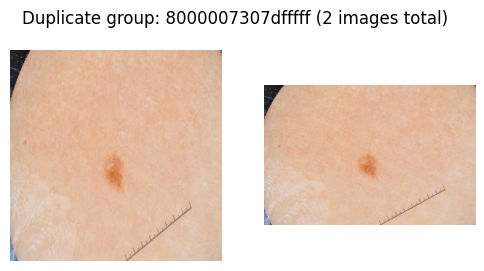

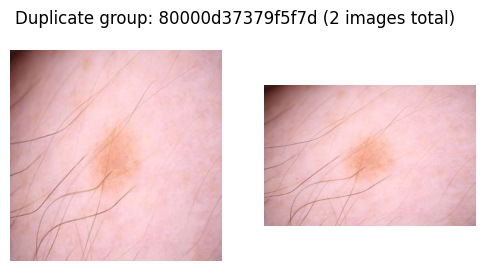

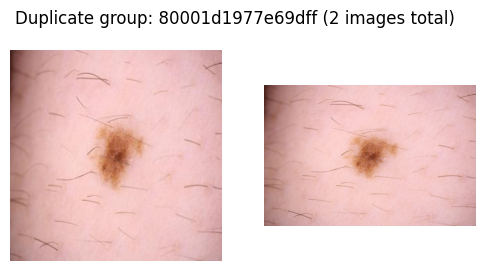

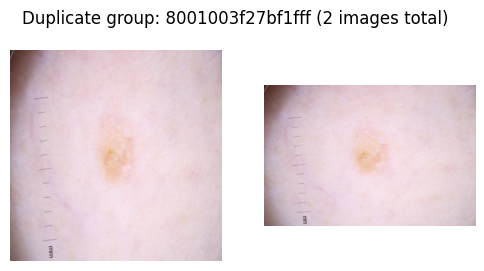

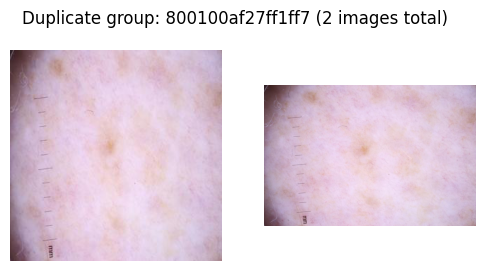

Deleting 5213 duplicates in parallel...


Deleting duplicates: 100%|██████████| 5213/5213 [00:01<00:00, 4446.76it/s]


Removed 5213 duplicate images and updated CSV.
Removed 5213 duplicate images (kept one per group).


In [ ]:
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
from helper_functions import compute_hash, show_duplicates

output_csv = os.path.join(DATA_PATH, "combined_labels.csv")
combined_df = pd.read_csv(output_csv)
combined_df["file_path"] = combined_df["new_filename"].apply(lambda x: os.path.join(DATA_PATH, "all_images", x))

# === Compute image hashes only if missing ===
if "hash" not in combined_df.columns or combined_df["hash"].isnull().any():
    print("Computing image hashes in parallel...")
    
    # Extract file paths to a list for the executor
    file_paths = combined_df["file_path"].tolist()
    hashes = [None] * len(file_paths)
    
    # Use ProcessPoolExecutor to use all CPU cores
    
    with ProcessPoolExecutor(max_workers=None) as executor:
        # Submit all tasks
        future_to_idx = {executor.submit(compute_hash, fp): i for i, fp in enumerate(file_paths)}
             
        for future in tqdm(as_completed(future_to_idx), total=len(file_paths), desc="Hashing images"):
            idx = future_to_idx[future]
            try:
                hashes[idx] = future.result()
            except Exception as e:
                print(f"Error hashing file index {idx}: {e}")
                hashes[idx] = None

    
    combined_df["hash"] = hashes
    combined_df = combined_df.dropna(subset=["hash"])
    combined_df.to_csv(output_csv, index=False)
    print("Hashes saved to CSV.")
else:
    print("Hashes already exist in CSV, skipping recomputation.")

# === Find duplicates by hash ===
dupe_hashes = combined_df[combined_df.duplicated('hash', keep=False)]
dupe_counts = dupe_hashes['hash'].value_counts()
print(f"Found {len(dupe_counts)} hash groups with duplicates ({dupe_hashes.shape[0]} total images).")
# Show samples of duplicates for sanity check
show_duplicates(combined_df, max_per_group=5)

# === Delete duplicate image files in parallel ===
dupes = combined_df[combined_df.duplicated("hash", keep="first")]
dupe_paths = dupes["file_path"].tolist()

if dupe_paths:
    print(f"Deleting {len(dupe_paths)} duplicates in parallel...")
    
    # Deleting files is mostly I/O bound, so ThreadPool or ProcessPool both work fine here.
    with ProcessPoolExecutor() as executor:
        # os.remove returns None, so we just map the function directly
        futures = {executor.submit(os.remove, fp): fp for fp in dupe_paths}
        
        for future in tqdm(as_completed(futures), total=len(dupe_paths), desc="Deleting duplicates"):
            fp = futures[future]
            try:
                future.result()
            except FileNotFoundError:
                pass # Already deleted or missing
            except Exception as e:
                print(f"Error deleting {fp}: {e}")

# === Drop rows for deleted images ===
clean_df = combined_df.drop_duplicates(subset="hash", keep="first")

clean_df.to_csv(output_csv, index=False)
print(f"Removed {len(dupes)} duplicate images and updated CSV.")

n_removed = len(combined_df) - len(clean_df)
print(f"Removed {n_removed} duplicate images (kept one per group).")

### 0.1.4 Final dataset path

In [ ]:
#Final data path
output_csv = DATA_PATH+"./combined_labels.csv"
df = pd.read_csv(output_csv)
df["file_path"] = df["new_filename"].apply(lambda x: os.path.join(DATA_PATH, "all_images", x))
print("Number of images kept: ", len(df))

39408


# 1. Dataset properties

## 1.1 Class distribution

In [3]:
from IPython.display import display, HTML

# 1. Format the value counts into a clean DataFrame
dist_df = df['label'].value_counts().to_frame().reset_index()
dist_df.columns = ['Class Label', 'Count']

# 2. Add a clean, bold Markdown header above the table
display(HTML("<h3>Class Distribution</h3>"))
display(dist_df)


,Class Label,Count
0,benign,34187
1,malignant,5221


## 1.2 Color Distribution

Checking for outliers if there are any

In [4]:
import numpy as np
from tqdm.contrib.concurrent import thread_map
from PIL import Image

def average_rgb_safe(img_path):
    try:
        with Image.open(img_path) as img:
            return np.array(img.convert('RGB')).mean(axis=(0,1))
    except Exception as e:
        return np.array([0.0, 0.0, 0.0])

results = thread_map(
    average_rgb_safe, 
    df['file_path'].tolist(), 
    max_workers=8,
    desc="Threading average color"
)

colors = np.array(results)



Threading average color:   0%|          | 0/39408 [00:00<?, ?it/s]

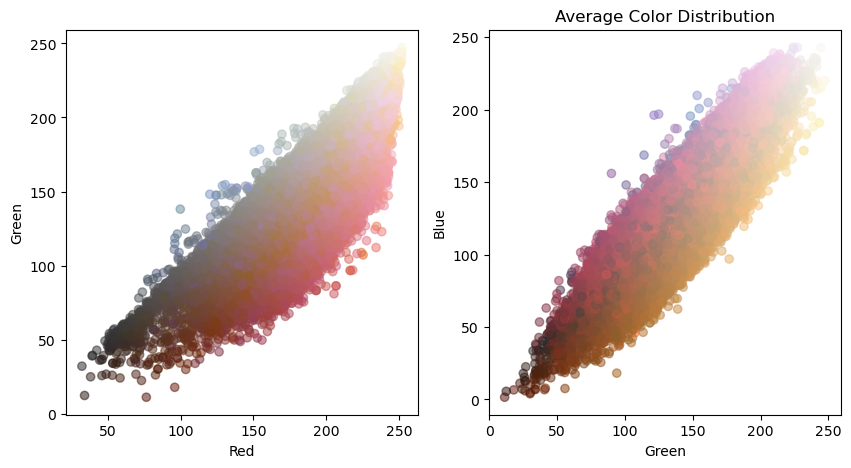

In [5]:
fig, axs = plt.subplots(1,2,figsize=(10,5))
axs[0].scatter(colors[:,0], colors[:,1], c=colors/255, alpha=0.5)
axs[0].set_xlabel("Red")
axs[0].set_ylabel("Green")
axs[1].scatter(colors[:,1], colors[:,2], c=colors/255, alpha=0.5)
axs[1].set_xlabel("Green")
axs[1].set_ylabel("Blue")
plt.title("Average Color Distribution")
plt.show()


## 1.3 Visual check up

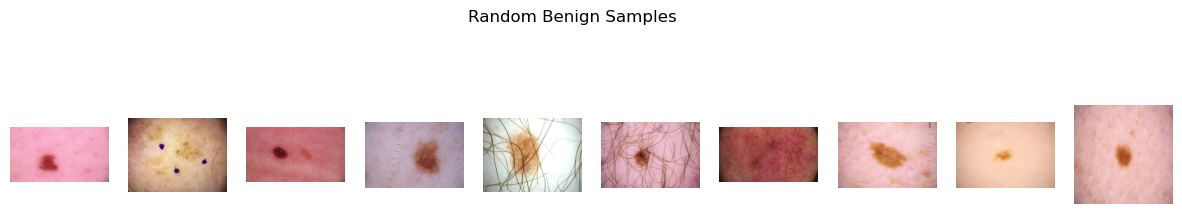

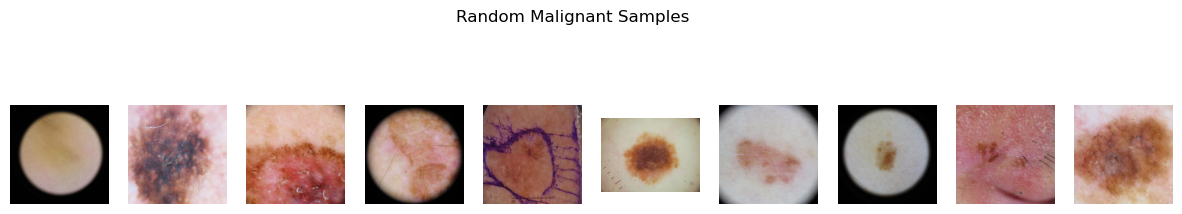

In [6]:
show_random_samples(df, 'benign', n = 10)
show_random_samples(df, 'malignant', n = 10)

# 2. Preprocessing pipeline

Images have two principal characteristics. One is the vignette, the other are the hair. We exploroe two simple approaches to deal with both.

## 2.1 Dealing with vignetting

In [9]:
# Testing the function to detect vignette borders
from helper_functions import has_vignette_border, show_border_samples
from tqdm.contrib.concurrent import thread_map

results = thread_map(
    has_vignette_border, 
    df['file_path'].tolist(), 
    max_workers=6,
    desc="Detecting vignette borders"
)
df['has_vignette_border'] = results

# --- CLEAN CONSOLE PRINT START ---
counts = df['has_vignette_border'].value_counts()
vignette_count = counts.get(True, 0)
normal_count = counts.get(False, 0)
total = len(df)

# Dynamic fallback safety in case total is 0 to avoid ZeroDivisionError
vignette_pct = (vignette_count / total * 100) if total > 0 else 0
normal_pct = (normal_count / total * 100) if total > 0 else 0

print("\n" + "="*45)
print(f" Total Images Processed : {total:,}")
print(f" Vignette Detected      : {vignette_count:,} ({vignette_pct:.1f}%)")
print(f" No Vignette  : {normal_count:,} ({normal_pct:.1f}%)")
print("="*45 + "\n")

show_border_samples(df, n=5)

Detecting vignette borders:   0%|          | 0/39408 [00:00<?, ?it/s]

KeyboardInterrupt: 

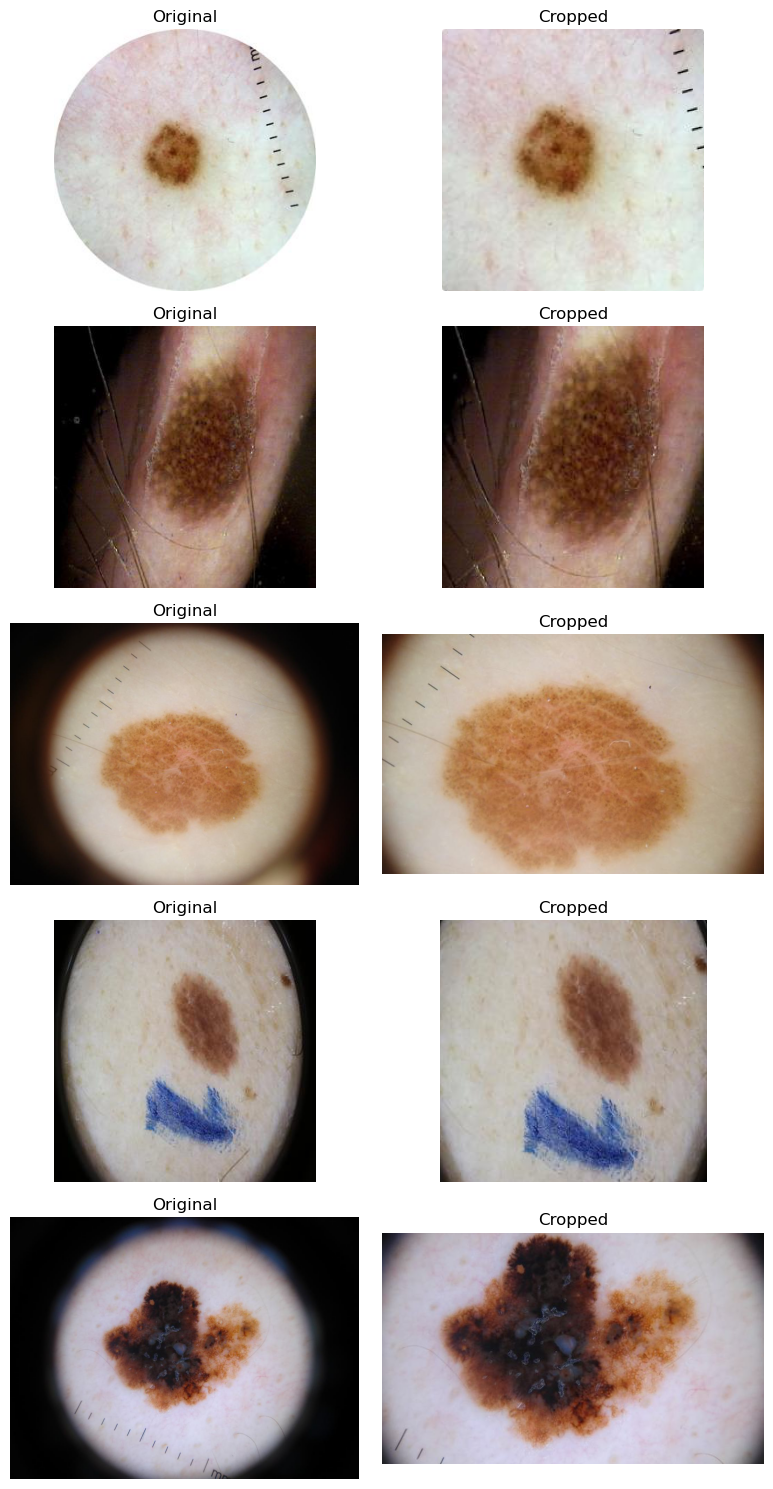

In [10]:
# Testing the cropping handler function
from helper_functions import crop_border, crop_to_detected_circle, show_before_after_crop

testing = True
if(testing):
    subset_df = df[df['has_vignette_border']].copy()
    subset_df = subset_df.iloc[:50]
    subset_df['processed_img'] = subset_df.apply(
        lambda row: crop_to_detected_circle(row['file_path']) 
        if row['has_vignette_border'] else Image.open(row['file_path']),
        axis=1
    )
    show_before_after_crop(subset_df, n=5)
else:
    # No need to run that part, it will be dealt with during the training
    df['processed_vignetting'] = clean_df.apply(
        lambda row: crop_to_detected_circle(row['file_path']) if row['has_vignette_border'] 
        else Image.open(row['file_path']), axis=1)
    show_before_after_crop(clean_df, n=5)

## 2.1 Hair removal

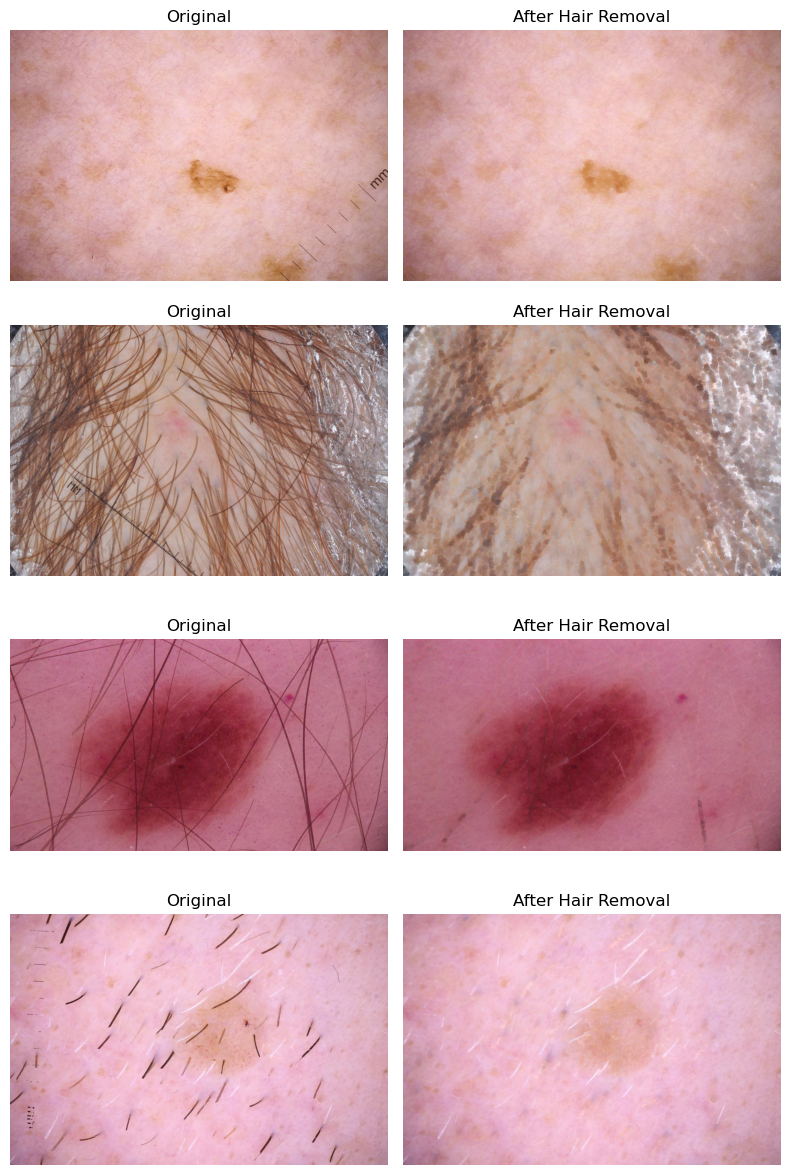

In [13]:
from helper_functions import remove_hair, show_hair_removal_samples

testing = True

if testing:
    imgnumber = ["044574", "044520", "044227", "043909"]
    
    def matches_target(path):
        if not isinstance(path, str):
            return False
        base = os.path.basename(path)
        return any(num in base for num in imgnumber)

    subset_df = df[df['file_path'].apply(matches_target)].copy()
    # Run the hair removal via list comprehension (safe for image objects)
    subset_df['processed_hair'] = [
        remove_hair(Image.open(fp)) if (fp and os.path.exists(fp)) else None 
        for fp in subset_df['file_path']
    ]
    # Visual check
    show_hair_removal_samples(subset_df)

else:
    # Also no need to run that part
    def process_row_safe(fp):
        try:
            if fp and os.path.exists(fp):
                with Image.open(fp) as img:
                    return remove_hair(img.convert("RGB"))
        except Exception as e:
            print(f"Error processing {fp}: {e}")
        return None

    df['processed_hair'] = thread_map(
        process_row_safe, 
        df['file_path'].tolist(), 
        max_workers=8, 
        desc="Removing hair from all images"
    )
    


# 3. Model training

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

import torch
import torchvision.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader, WeightedRandomSampler

import random
from datetime import datetime

import numpy as np

## 3.1 Framework definition

### 3.1.1 Model

In [ ]:
# Load a pretrained MobileNetV3 model (lightweight, fast, mobile-friendly)
def create_model(freeze_backbone=False):
    try:
      weights = models.MobileNet_V3_Small_Weights.DEFAULT
      model = models.mobilenet_v3_small(weights=weights)
    except Exception:
      print("Couldn't load pretrained weights, using random initialization instead.")
      model = models.mobilenet_v3_small(pretrained=True)

    # Replace final layer with one binary output (logit)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, 1)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False  # freeze encoder

    return model.to(device)

def set_seed(seed=33): #setting the seed for reproducing later if needed
    random.seed(seed)                     
    np.random.seed(seed)                  
    torch.manual_seed(seed)                # PyTorch (CPU)
    if torch.cuda.is_available():          # PyTorch (GPU)
        torch.cuda.manual_seed_all(seed)

set_seed()  

# Use GPU if available (faster); otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device used: ", device)

model = create_model()


Device used:  cpu


In [17]:
from torchinfo import summary

# Define your input size matching your dataset (e.g., Batch Size 1, 3 Channels, 224x224)
# This simulates a pass through the network to calculate output dimensions
summary(model, input_size=(1, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Trainable
MobileNetV3                                        [1, 3, 224, 224]          [1, 1]                    --                        True
├─Sequential: 1-1                                  [1, 3, 224, 224]          [1, 576, 7, 7]            --                        True
│    └─Conv2dNormActivation: 2-1                   [1, 3, 224, 224]          [1, 16, 112, 112]         --                        True
│    │    └─Conv2d: 3-1                            [1, 3, 224, 224]          [1, 16, 112, 112]         432                       True
│    │    └─BatchNorm2d: 3-2                       [1, 16, 112, 112]         [1, 16, 112, 112]         32                        True
│    │    └─Hardswish: 3-3                         [1, 16, 112, 112]         [1, 16, 112, 112]         --                        --
│    └─InvertedResidual: 2-2                       [1, 16, 

### 3.1.2 Train/Val split

In [ ]:
# # Class distribution
# output_csv = DATA_PATH+"./combined_labels.csv"
# df = pd.read_csv(output_csv)
# df["file_path"] = df["new_filename"].apply(lambda x: os.path.join(DATA_PATH, "all_images", x))

# First split: train + temp_valtest
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,  # 30% reserved for val + test
    stratify=df['label'],
    random_state=35
)

# Second split: val + test from temp
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # half of 30% = 15% test, 15% val
    stratify=temp_df['label'],
    random_state=35
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

# persist split for reproducibility
split_id = random.randint(10000, 99999)

# Create dated folder with the split ID
today = datetime.today().strftime("%Y-%m-%d")
folder_name = f"../models/splits_{today}_{split_id}"
os.makedirs(folder_name, exist_ok=True)

# Save train/val CSVs with split ID in filenames
train_df.to_csv(f"{folder_name}/split_{split_id}_train.csv", index=False)
val_df.to_csv(f"{folder_name}/split_{split_id}_val.csv", index=False)
test_df.to_csv(f"{folder_name}/split_{split_id}_test.csv", index=False)

print(f"Split saved in folder '{folder_name}' with ID {split_id}")

Train size: 27585
Val size: 5911
Test size: 5912
✅ Split saved in folder '../models/splits_2026-05-28_84754' with ID 84754


We have way more benign then maignant, and the training must account for this imbalance

In [19]:
# Imbalance 
counts = train_df['label'].value_counts()
neg, pos = int(counts.get('benign', 0)), int(counts.get('malignant', 0))
pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32)

# Calculate distribution metrics
total = neg + pos
neg_pct = (neg / total * 100) if total > 0 else 0
pos_pct = (pos / total * 100) if total > 0 else 0

print("\n" + "="*50)
print(" DATASET IMBALANCE & LOSS WEIGHTING REPORT")
print("="*50)
print(f" Benign (Negative Class)    : {neg:,} ({neg_pct:.1f}%)")
print(f" Malignant (Positive Class) : {pos:,} ({pos_pct:.1f}%)")
print(f" Total Training Samples     : {total:,}")
print("-"*50)
print(f" Calculated pos_weight      : {pos_weight.item():.4f}")
print(f" Multiplier Ratio           : {pos_weight.item():.2f}:1")
print("="*50 + "\n")



 DATASET IMBALANCE & LOSS WEIGHTING REPORT
 Benign (Negative Class)    : 23,930 (86.8%)
 Malignant (Positive Class) : 3,655 (13.2%)
 Total Training Samples     : 27,585
--------------------------------------------------
 Calculated pos_weight      : 6.5472
 Multiplier Ratio           : 6.55:1



In [ ]:
# Loss with computed pos_weight
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

### 3.1.3 Preprocessing/augmentation pipeling definition

In [21]:
from PIL import Image

IMG_SIZE = 224  #default for now
DO_VIGNETTE = False
DO_HAIR = False

class MelanomaDataset(Dataset):
    def __init__(self, df, transform, use_hair, use_vignette):
        self.paths = df['file_path'].tolist()
        self.labels = (df['label'] == 'malignant').astype('int64').tolist() #1 malignant, 0 benign
        self.transform = transform
        self.use_hair = use_hair
        self.use_vignette = use_vignette

    def __len__(self): 
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = preprocess_pil(p, do_vignette=self.use_vignette, do_hair=self.use_hair)
        img = self.transform(img)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, y

def preprocess_pil(img_path, do_vignette=DO_VIGNETTE, do_hair=DO_HAIR):
    img = Image.open(img_path).convert('RGB')
    if do_vignette and has_vignette_border(img_path):
        img = crop_to_detected_circle(img_path)  # your robust version
    if do_hair:
        img = remove_hair(img)   # inpainting-based
    return img

# this function
def estimate_norm(df, do_vignette, do_hair, n=600):
    paths = df.sample(min(n, len(df)), random_state=33)['file_path'].tolist()
    to_tensor = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])
    acc = []
    for p in paths:
        img = preprocess_pil(p, do_vignette=do_vignette, do_hair=do_hair)
        acc.append(to_tensor(img))
    stack = torch.stack(acc)
    return stack.mean(dim=(0,2,3)).tolist(), stack.std(dim=(0,2,3)).tolist()

### 3.1.4 Experiment run framework

In [ ]:
def run_experiment(recipe_name, do_vignette, do_hair, epochs=10):
    print(f"\n STARTING EXPERIMENT: {recipe_name} (Vignette={do_vignette}, Hair={do_hair})")
    
    # Calculate normalization stats
    mean, std = estimate_norm(train_df, do_vignette=do_vignette, do_hair=do_hair, n=600)
    print("Norm stats (training set):", mean, std)
    
    # Define Transforms using these specifics, we could change some values, but we'll keep it simple
    train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)), 
    T.RandomHorizontalFlip(),            
    T.RandomRotation(20), 
    T.ColorJitter(0.15, 0.15, 0.15, 0.08), # (brightness, contrast, saturation, hue).
    T.ToTensor(),                           
    T.Normalize(mean, std),                
])
    val_tfms = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean, std)
    ])
    
    # Create DataLoaders
    train_ds = MelanomaDataset(train_df, train_tfms, use_hair=do_hair, use_vignette=do_vignette)
    val_ds   = MelanomaDataset(val_df,   val_tfms,   use_hair=do_hair, use_vignette=do_vignette)
    
    labels = train_df['label'].values
    class_weights = [1. / np.sum(labels == label) for label in labels]
    sampler = WeightedRandomSampler(class_weights, len(class_weights))
    
    train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler, num_workers=6, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=6, pin_memory=False)
    
    # Initialize a clean model architecture instance for this run
    model = create_model().to(device)
    
    # Custom path for this model recipe's weights
    ckpt_path = folder_name+f"/model_{recipe_name}.pt"
    
    # Run fit loop (Passes mean/std explicitly to fit function so it saves correctly)
    print(f"Starting FIT")
    history, saved_path = fit(
        model, train_loader, val_loader, epochs=epochs, 
        ckpt_path=ckpt_path, patience=3, mean=mean, std=std
    )
    
    # history, ckpt = fit(model, train_loader, val_loader,
    #                 epochs=12, lr=1e-4, wd=1e-4, patience=3)
    # Convert history log to DataFrame and append recipe details
    history_df = pd.DataFrame(history)
    history_df["recipe"] = recipe_name
    
    return history_df
# This function runs on the validation set without updating the model

def evaluate(model, loader):
    model.eval()  # evaluation mode
    all_logits, all_y = [], []  # to collect predictions and true labels
    total_loss = 0.0

    with torch.no_grad():  # no gradients needed in eval
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)  # move to GPU/CPU
            logits = model(xb).squeeze(1)          # forward pass
            loss = loss_fn(logits, yb)
            total_loss += loss.item() * xb.size(0)

            all_logits.append(logits.cpu())        # store predictions
            all_y.append(yb.cpu())                 # store labels

    # Combine all batches
    logits = torch.cat(all_logits).numpy()
    y_true = torch.cat(all_y).numpy()

    # Convert logits to probabilities
    probs = 1 / (1 + np.exp(-logits))

    # Compute AUC (how well the model separates classes)
    try:
        auc = roc_auc_score(y_true, probs)
    except ValueError:
        auc = float('nan')

    # Compute PR-AUC (how good the model is at finding positives), important for imbalanced datasets
    try:
        pr_auc = average_precision_score(y_true, probs)
    except ValueError:
        pr_auc = float('nan')

    avg_loss = total_loss / len(loader.dataset)
    return {"loss": avg_loss, "auc": auc, "pr_auc": pr_auc}

def train_one_epoch(model, loader, optimizer, scaler=None):
    model.train()  # set model to training mode
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        # print("Batch:", xb.shape, yb.shape, "malignant frac in batch:", float(yb.mean().item()))
        optimizer.zero_grad(set_to_none=True)  # reset gradients

        if scaler is None:  # standard training (no mixed precision)
            logits = model(xb).squeeze(1)  # get predictions
            loss = loss_fn(logits, yb)
            loss.backward()               # compute gradients
            optimizer.step()              # update weights
        else:  # mixed precision for faster training on GPU
            with torch.cuda.amp.autocast():
                logits = model(xb).squeeze(1)
                loss = loss_fn(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        total_loss += loss.item() * xb.size(0)  # accumulate batch loss

    return total_loss / len(loader.dataset)  # average over all data



def fit(model, train_loader, val_loader, epochs=10, lr=1e-4, wd=1e-4,
        patience=3, ckpt_path="models/baseline_mnv3.pt", mean=0, std=0):

    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scaler = torch.amp.GradScaler() if device.type == 'cuda' else None

    best_auc = -float('inf')
    best_state = None
    wait = 0
    history = []

    for epoch in range(1, epochs+1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, train_loader, optimizer, scaler)
        val_metrics = evaluate(model, val_loader)
        history.append({"epoch": epoch, "train_loss": tr_loss, **val_metrics})

        # Save best model based on val AUC
        improved = val_metrics["pr_auc"] > best_auc
        if improved:
            best_auc = val_metrics["pr_auc"]
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            torch.save({"state_dict": best_state, "mean": mean, "std": std}, ckpt_path)
            wait = 0  # reset patience counter
        else:
            wait += 1

        dt = time.time() - t0
        print(f"Epoch {epoch:02d} | tr_loss {tr_loss:.4f} | val_loss {val_metrics['loss']:.4f} | "
              f"val_auc {val_metrics['auc']:.4f} | val_prAUC {val_metrics['pr_auc']:.4f} | {dt:.1f}s"
              + ("  *" if improved else ""))

        if wait >= patience:
            print(f"Early stopping (no AUC improvement for {patience} epochs).")
            break

    # Load best model back into memory
    if best_state is not None:
        model.load_state_dict(best_state)

    return history, ckpt_path


## 3.2 Training

### Create Model

In [ ]:
# 1. Define recipes: (Name, DO_VIGNETTE, DO_HAIR)
recipes = [
    ("baseline",        False, False),
    # ("vignette_only",   True,  False),
    ("hair_only",       False, True),
    # ("full_processed",  True,  True)
]

all_results = []

# 2. Iterate and train
for name, vig, hair in recipes:
    res_df = run_experiment(recipe_name=name, do_vignette=vig, do_hair=hair, epochs=10)
    all_results.append(res_df)

# 3. Concatenate and sort to see which preprocessing strategy wins!
comparison_df = pd.concat(all_results, ignore_index=True)

# Find the best epoch result for each recipe based on Validation PR-AUC
best_per_recipe = comparison_df.sort_values("pr_auc", ascending=False).drop_duplicates(["recipe"])
print("\n FINAL RECIPE COMPARISON LEADERBOARD:")
print(best_per_recipe[["recipe", "epoch", "train_loss", "loss", "auc", "pr_auc"]])


 STARTING EXPERIMENT: baseline (Vignette=False, Hair=False)
Norm stats (training set): [0.7820616364479065, 0.6049866676330566, 0.5777014493942261] [0.17382073402404785, 0.1868813931941986, 0.2065434604883194]
Starting FIT
Epoch 01 | tr_loss 0.5283 | val_loss 0.5178 | val_auc 0.9880 | val_prAUC 0.9464 | 223.8s  *
Epoch 02 | tr_loss 0.3407 | val_loss 0.3106 | val_auc 0.9890 | val_prAUC 0.9582 | 219.6s  *
Epoch 03 | tr_loss 0.2867 | val_loss 0.5214 | val_auc 0.9888 | val_prAUC 0.9562 | 218.2s
Epoch 04 | tr_loss 0.2186 | val_loss 0.2783 | val_auc 0.9913 | val_prAUC 0.9618 | 220.5s  *
Epoch 05 | tr_loss 0.1983 | val_loss 0.3035 | val_auc 0.9904 | val_prAUC 0.9635 | 219.8s  *
Epoch 06 | tr_loss 0.1668 | val_loss 0.3123 | val_auc 0.9907 | val_prAUC 0.9609 | 221.1s
Epoch 07 | tr_loss 0.1533 | val_loss 0.3225 | val_auc 0.9917 | val_prAUC 0.9667 | 219.7s  *
Epoch 08 | tr_loss 0.1287 | val_loss 0.2557 | val_auc 0.9915 | val_prAUC 0.9666 | 217.3s
Epoch 09 | tr_loss 0.1161 | val_loss 0.2934 | val

KeyError: 'val_pr_auc'

In [30]:
# Find the best epoch result for each recipe based on Validation PR-AUC
best_per_recipe = comparison_df.sort_values("pr_auc", ascending=False).drop_duplicates(["recipe"])
print("\n FINAL RECIPE COMPARISON LEADERBOARD:")
print(best_per_recipe[["recipe", "epoch", "train_loss", "loss", "auc", "pr_auc"]])


 FINAL RECIPE COMPARISON LEADERBOARD:
       recipe  epoch  train_loss      loss       auc    pr_auc
18  hair_only      9    0.139815  0.236950  0.992607  0.969323
6    baseline      7    0.153321  0.322548  0.991726  0.966667


In [195]:
filename = f"{folder_name}/{split_id}_mole_classifier.pth"
torch.save(model.state_dict(), filename)


# 4. Validate performance

## 4.1 Validation datasets, check diff

-> Extracting predictions for recipe: baseline

 MEDICAL PERFORMANCE ANALYSIS: BASELINE
              precision    recall  f1-score   support

      benign       1.00      0.90      0.95      5128
   malignant       0.60      0.98      0.75       783

    accuracy                           0.91      5911
   macro avg       0.80      0.94      0.85      5911
weighted avg       0.95      0.91      0.92      5911

-> Extracting predictions for recipe: hair_only

 MEDICAL PERFORMANCE ANALYSIS: HAIR_ONLY
              precision    recall  f1-score   support

      benign       1.00      0.94      0.97      5128
   malignant       0.71      0.97      0.82       783

    accuracy                           0.94      5911
   macro avg       0.85      0.95      0.89      5911
weighted avg       0.96      0.94      0.95      5911



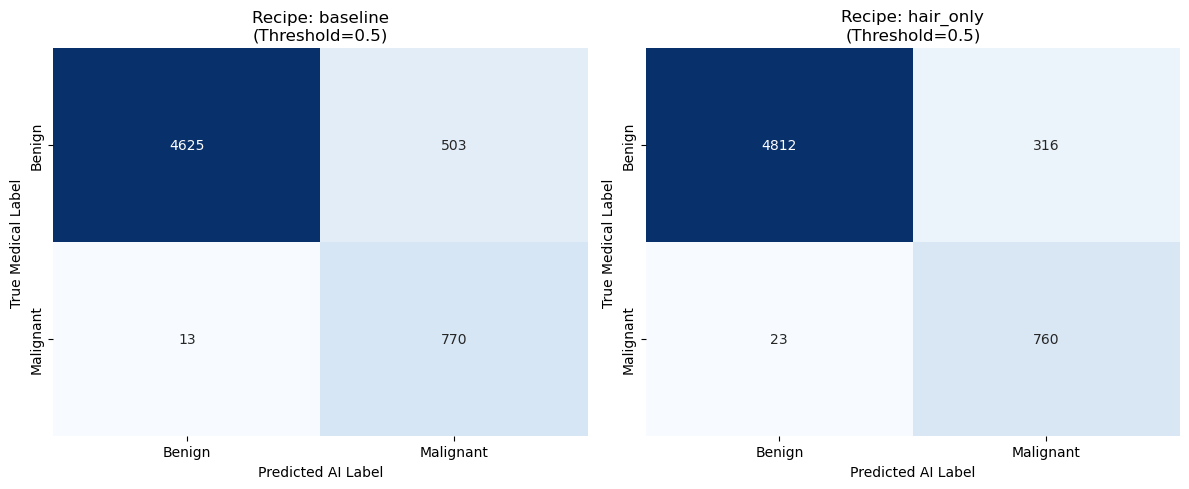

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

def get_predictions_consistent(recipe_name, df, do_vignette, do_hair):
    """
    Loads the best saved model checkpoint and extracts its unique 
    normalization statistics to cleanly evaluate the validation dataframe.
    """
    print(f"-> Extracting predictions for recipe: {recipe_name}")
    
    # 1. Point to your saved recipe file and load the dictionary
    ckpt_path = folder_name + f"/model_{recipe_name}.pt"
    checkpoint = torch.load(ckpt_path, map_location=device)
    
    # 2. Extract the exact mean and std tailored to this recipe run
    mean = checkpoint["mean"]
    std = checkpoint["std"]
    
    # 3. Build validation transforms using these explicit stats
    val_tfms = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean, std)
    ])
    
    # 4. Construct dataset and loader
    eval_ds = MelanomaDataset(df, val_tfms, use_hair=do_hair, use_vignette=do_vignette)
    eval_loader = DataLoader(eval_ds, batch_size=64, shuffle=False, num_workers=6, pin_memory=False)
    
    # 5. Initialize fresh model architecture and inject the weights
    model = create_model().to(device)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    
    all_probs, all_y = [], []
    with torch.no_grad():
        for xb, yb in eval_loader:
            xb = xb.to(device)
            logits = model(xb).squeeze(1)
            
            # Match the algebraic sigmoid conversion used in your evaluate() function
            probs = 1 / (1 + torch.exp(-logits)) 
            
            all_probs.append(probs.cpu())
            all_y.append(yb.cpu())
            
    return torch.cat(all_probs).numpy(), torch.cat(all_y).numpy()

# Decision boundary for classification (0.5 is default)
THRESHOLD = 0.5 

# Dynamically set up side-by-side plots based on your active recipes array
fig, axes = plt.subplots(1, len(recipes), figsize=(6 * len(recipes), 5))
if len(recipes) == 1: 
    axes = [axes]

# Loop through active pipeline configurations
for ax, (name, vig, hair) in zip(axes, recipes):
    
    # Generate predictions safely using validation dataframe
    probs, y_true = get_predictions_consistent(name, val_df, do_vignette=vig, do_hair=hair)
    y_pred = (probs >= THRESHOLD).astype(int)
    
    # Print the detailed text classification metrics to your terminal
    print("\n" + "="*60)
    print(f" MEDICAL PERFORMANCE ANALYSIS: {name.upper()}")
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=["benign", "malignant"]))
    
    # Compute and plot visual confusion matrix layout
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Benign', 'Malignant'], 
                yticklabels=['Benign', 'Malignant'])
    ax.set_title(f"Recipe: {name}\n(Threshold={THRESHOLD})")
    ax.set_ylabel('True Medical Label')
    ax.set_xlabel('Predicted AI Label')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

def plot_compare_curves(recipe_predictions):
    """
    Plots overlaid ROC and Precision-Recall curves for multiple experiments.
    
    Parameters:
    recipe_predictions (dict): A dictionary structured as:
                               { "recipe_name": (y_true_array, y_score_array) }
    """
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    axs[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label="Random Guess (AUC = 0.500)")
    
    for idx, (name, (y_true, y_score)) in enumerate(recipe_predictions.items()):
        color = colors[idx % len(colors)]
        
        # Calculate curve coordinates
        fpr, tpr, _ = roc_curve(y_true, y_score)
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        
        # Calculate exact area under the curves
        roc_auc = auc(fpr, tpr)
        pr_auc = auc(recall, precision) # Metrics calculation
        
        # Plot ROC Curve
        axs[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", color=color, lw=2)
        
        # Plot Precision-Recall Curve
        axs[1].plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.3f})", color=color, lw=2)
        
    # --- Format ROC Subplot ---
    axs[0].set_title("ROC Curve Comparison", fontsize=14, fontweight='bold', pad=10)
    axs[0].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
    axs[0].set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=11)
    axs[0].set_xlim([-0.02, 1.02])
    axs[0].set_ylim([-0.02, 1.02])
    axs[0].grid(True, linestyle=':', alpha=0.6)
    axs[0].legend(loc="lower right", frameon=True)

    # --- Format Precision-Recall Subplot ---
    axs[1].set_title("Precision–Recall Curve Comparison", fontsize=14, fontweight='bold', pad=10)
    axs[1].set_xlabel("Recall (Sensitivity)", fontsize=11)
    axs[1].set_ylabel("Precision (Positive Predictive Value)", fontsize=11)
    axs[1].set_xlim([-0.02, 1.02])
    axs[1].set_ylim([-0.02, 1.02])
    axs[1].grid(True, linestyle=':', alpha=0.6)
    axs[1].legend(loc="lower left", frameon=True)

    plt.tight_layout()
    plt.show()


Gathering curve coordinates for all experiments...
-> Extracting predictions for recipe: baseline
-> Extracting predictions for recipe: hair_only


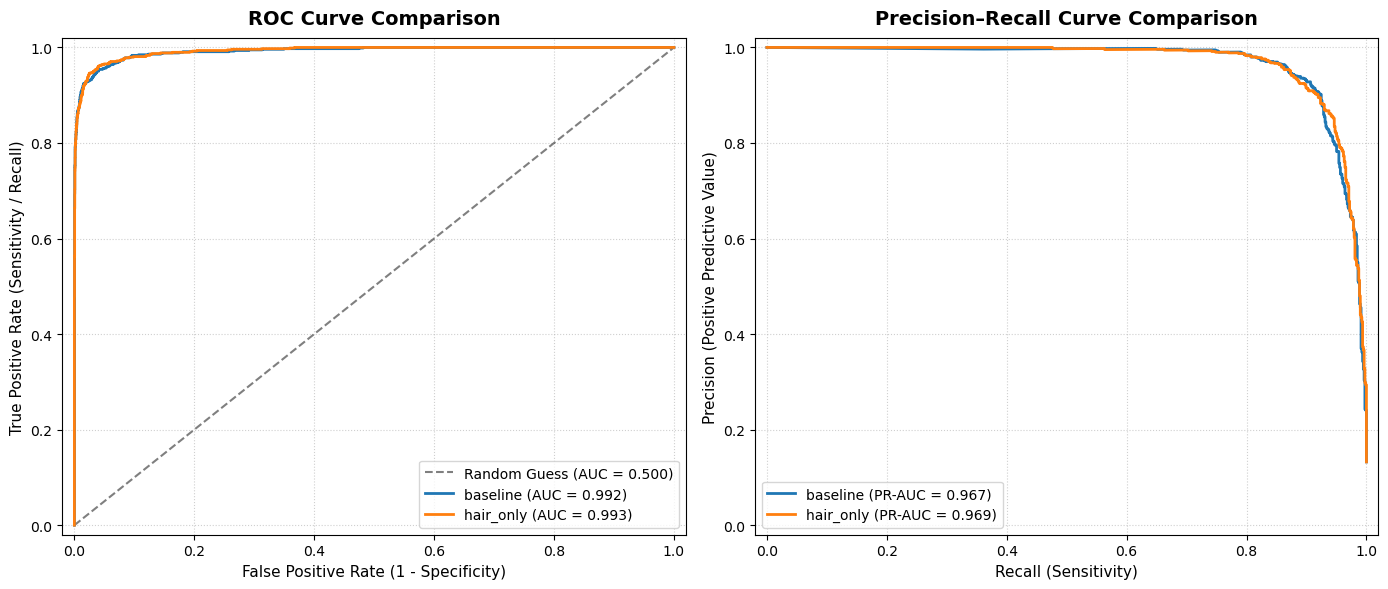

In [ ]:
# Create an empty dictionary to collect predictions across all runs
all_recipe_preds = {}

print("\nGathering curve coordinates for all experiments...")
for name, vig, hair in recipes:
    probs, y_true = get_predictions_consistent(name, val_df, do_vignette=vig, do_hair=hair)
    all_recipe_preds[name] = (y_true, probs)

plot_compare_curves(all_recipe_preds)

In [34]:
from sklearn.metrics import roc_curve, precision_recall_curve
import numpy as np

def find_optimal_thresholds(y_true, y_score, recipe_name):
    print(f"\n" + "="*50)
    print(f" OPTIMIZING THRESHOLDS FOR: {recipe_name.upper()}")
    print("="*50)
    
    # ----------------------------------------------------
    # Method 1: Youden's J-Statistic (Best General Balance)
    # ----------------------------------------------------
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    # J = True Positive Rate - False Positive Rate
    youdens_j = tpr - fpr
    best_idx_j = np.argmax(youdens_j)
    thresh_j = roc_thresholds[best_idx_j]
    
    print(f"1. Youden's J-Statistic Optimal Threshold: {thresh_j:.4f}")
    print(f"   -> Resulting Recall (Sensitivity): {tpr[best_idx_j]:.3f}")
    print(f"   -> Resulting False Positive Rate: {fpr[best_idx_j]:.3f}")
    
    # ----------------------------------------------------
    # Method 2: F1-Score Maximization (Best for Imbalance)
    # ----------------------------------------------------
    precisions, recalls, pr_thresholds = precision_recall_curve(y_true, y_score)
    # Calculate F1 score for each threshold point
    # (add a tiny epsilon to avoid division by zero)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx_f1 = np.argmax(f1_scores)
    
    # Note: precision_recall_curve returns 1 more value for precision/recall than thresholds
    thresh_f1 = pr_thresholds[best_idx_f1] if best_idx_f1 < len(pr_thresholds) else pr_thresholds[-1]
    
    print(f"\n2. Max F1-Score Optimal Threshold: {thresh_f1:.4f}")
    print(f"   -> Resulting Precision: {precisions[best_idx_f1]:.3f}")
    print(f"   -> Resulting Recall: {recalls[best_idx_f1]:.3f}")
    
    # ----------------------------------------------------
    # Method 3: Clinical Requirement (e.g., Force 98% Recall)
    # ----------------------------------------------------
    # Find the highest threshold that still guarantees at least 98% Recall
    target_recall = 0.98
    clinical_idx = np.where(recalls >= target_recall)[0][-1]
    thresh_clinical = pr_thresholds[clinical_idx] if clinical_idx < len(pr_thresholds) else pr_thresholds[-1]
    
    print(f"\n3. Clinical Target Threshold (Force >= {target_recall*100}% Recall): {thresh_clinical:.4f}")
    print(f"   -> Resulting Precision: {precisions[clinical_idx]:.3f}")
    
    return {"youdens": thresh_j, "max_f1": thresh_f1, "clinical": thresh_clinical}

# --- How to run it ---
# (Using the 'all_recipe_preds' dictionary created in the previous step)
for name, (y_true, probs) in all_recipe_preds.items():
    threshold_dict = find_optimal_thresholds(y_true, probs, name)


 OPTIMIZING THRESHOLDS FOR: BASELINE
1. Youden's J-Statistic Optimal Threshold: 0.9304
   -> Resulting Recall (Sensitivity): 0.954
   -> Resulting False Positive Rate: 0.041

2. Max F1-Score Optimal Threshold: 0.9935
   -> Resulting Precision: 0.928
   -> Resulting Recall: 0.907

3. Clinical Target Threshold (Force >= 98.0% Recall): 0.5338
   -> Resulting Precision: 0.613

 OPTIMIZING THRESHOLDS FOR: HAIR_ONLY
1. Youden's J-Statistic Optimal Threshold: 0.8767
   -> Resulting Recall (Sensitivity): 0.946
   -> Resulting False Positive Rate: 0.025

2. Max F1-Score Optimal Threshold: 0.9824
   -> Resulting Precision: 0.951
   -> Resulting Recall: 0.874

3. Clinical Target Threshold (Force >= 98.0% Recall): 0.1917
   -> Resulting Precision: 0.603


In [200]:
def show_misclassified(df, y_true, y_pred, kind="fp", max_imgs=6):
    """
    kind = "fp" (false positives) → predicted malignant, actually benign
         = "fn" (false negatives) → predicted benign, actually malignant
    """
    mismatches = []
    for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
        if kind == "fp" and yt == 0 and yp == 1:
            mismatches.append(i)
        elif kind == "fn" and yt == 1 and yp == 0:
            mismatches.append(i)

    print(f"Found {len(mismatches)} {kind.upper()}s.")
    if not mismatches:
        return

    indices = mismatches[:max_imgs]
    fig, axs = plt.subplots(1, len(indices), figsize=(15, 5))
    for ax, idx in zip(axs, indices):
        path = df.iloc[idx]['file_path']
        ax.imshow(Image.open(path))
        ax.axis('off')
        ax.set_title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
    plt.show()


Found 348 FPs.


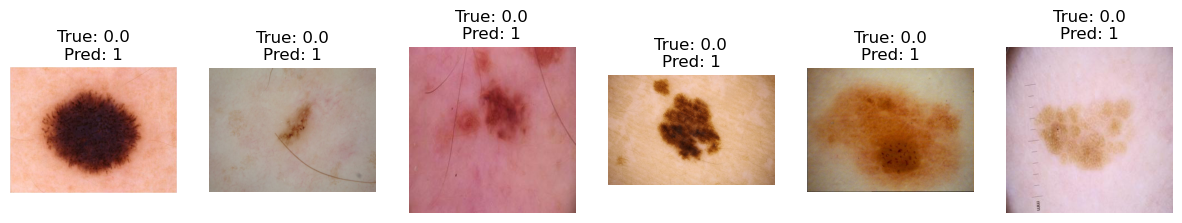

Found 22 FNs.


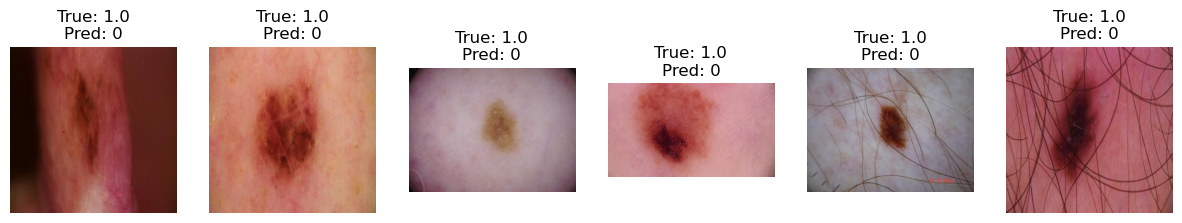

In [201]:
show_misclassified(val_df, y_true, y_pred, kind="fp")  # False Positives
show_misclassified(val_df, y_true, y_pred, kind="fn")  # False Negatives


## 4.2 Test dataset


 FINAL UNBIASED PERFORMANCE EVALUATION ON TEST DATA
 Champion Recipe: baseline | Threshold: 0.53

--- FINAL TEST CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      benign       1.00      0.91      0.95      5129
   malignant       0.62      0.97      0.75       783

    accuracy                           0.92      5912
   macro avg       0.81      0.94      0.85      5912
weighted avg       0.94      0.92      0.92      5912



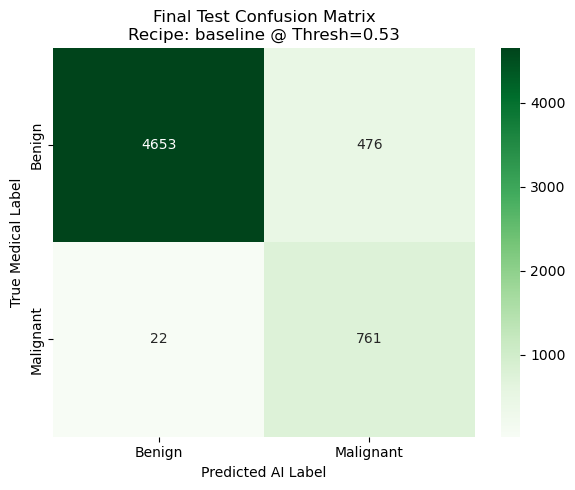

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

CHAMPION_RECIPE = "baseline"  # e.g., "baseline" or "hair_only"
FINAL_THRESHOLD = 0.53        # Use the optimal threshold you found earlier

recipe_map = {name: (vig, hair) for name, vig, hair in recipes}
if CHAMPION_RECIPE not in recipe_map:
    raise ValueError(f"Recipe '{CHAMPION_RECIPE}' not found in your recipes list.")

do_vignette, do_hair = recipe_map[CHAMPION_RECIPE]

print(f"\n" + "="*60)
print(f" FINAL UNBIASED PERFORMANCE EVALUATION ON TEST DATA")
print(f" Champion Recipe: {CHAMPION_RECIPE} | Threshold: {FINAL_THRESHOLD}")
print("="*60)


# Load the saved model dictionary to grab its unique mean/std stats
ckpt_path = folder_name + f"/model_{CHAMPION_RECIPE}.pt"
checkpoint = torch.load(ckpt_path, map_location=device)
mean = checkpoint["mean"]
std = checkpoint["std"]

# Build validation transforms using these explicit stats
test_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean, std)
])

# Using test_df
test_ds = MelanomaDataset(test_df, test_tfms, use_hair=do_hair, use_vignette=do_vignette)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=6, pin_memory=False)

# Load weights into the model architecture
model = create_model().to(device)
model.load_state_dict(checkpoint["state_dict"])
model.eval()

# GENERATE TEST PREDICTIONS
all_probs, all_y = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb).squeeze(1)
        probs = 1 / (1 + torch.exp(-logits))  # Sigmoid conversion
        
        all_probs.append(probs.cpu())
        all_y.append(yb.cpu())

y_true = torch.cat(all_y).numpy()
y_score = torch.cat(all_probs).numpy()
y_pred = (y_score >= FINAL_THRESHOLD).astype(int)


# Print final text metrics
print("\n--- FINAL TEST CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=["benign", "malignant"]))

# Plot final confusion matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Green theme to signify final test results
            xticklabels=['Benign', 'Malignant'], 
            yticklabels=['Benign', 'Malignant'])
plt.title(f"Final Test Confusion Matrix\nRecipe: {CHAMPION_RECIPE} @ Thresh={FINAL_THRESHOLD}")
plt.ylabel('True Medical Label')
plt.xlabel('Predicted AI Label')
plt.tight_layout()
plt.show()


## OLD TESTS
# | Class         | Precision | Recall   | F1-score | Support |
# | ------------- | --------- | -------- | -------- | ------- |
# | Benign        | **0.99**  | 0.95     | 0.97     | 5129    |
# | Malignant     | 0.74      | **0.97** | 0.84     | 783     |
# | Accuracy      |           |          | **0.95** | 5912    |
# | Macro Avg     | 0.87      | 0.96     | 0.90     |         |
# | Weighted Avg  | 0.96      | 0.95     | 0.95     |         |

## 4.3 Save results

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

all_recipe_metrics = []

for name, vig, hair in recipes:
    probs, y_true = get_predictions_consistent(name, val_df, do_vignette=vig, do_hair=hair)
    y_pred = (probs >= THRESHOLD).astype(int)
    
    report_dict = classification_report(
        y_true, 
        y_pred, 
        target_names=["benign", "malignant"], 
        output_dict=True
    )
    
    # Extract and organize the exact metrics for this specific recipe
    recipe_row = {
        "recipe_name": name,
        
        # Overall Model Performance
        "accuracy": report_dict["accuracy"],
        
        # Malignant Class Performance (Most Critical for Melanoma)
        "malignant_precision": report_dict["malignant"]["precision"],
        "malignant_recall": report_dict["malignant"]["recall"],
        "malignant_f1_score": report_dict["malignant"]["f1-score"],
        "malignant_support": report_dict["malignant"]["support"],
        
        # Benign Class Performance
        "benign_precision": report_dict["benign"]["precision"],
        "benign_recall": report_dict["benign"]["recall"],
        "benign_f1_score": report_dict["benign"]["f1-score"],
        "benign_support": report_dict["benign"]["support"],
        
        # Global Averages
        "macro_avg_f1": report_dict["macro avg"]["f1-score"],
        "weighted_avg_f1": report_dict["weighted avg"]["f1-score"]
    }
    
    all_recipe_metrics.append(recipe_row)

master_metrics_df = pd.DataFrame(all_recipe_metrics)

csv_output_path = folder_name + "/all_recipes_summary_metrics.csv"
master_metrics_df.to_csv(csv_output_path, index=False)

print(f"\n Master metrics file successfully compiled and saved to:")
print(f" -> {csv_output_path}")

print("\n--- MASTER METRICS OVERVIEW ---")
print(master_metrics_df.to_string(index=False))

-> Extracting predictions for recipe: baseline
-> Extracting predictions for recipe: hair_only

 Master metrics file successfully compiled and saved to:
 -> ../models/splits_2026-05-28_84754/all_recipes_summary_metrics.csv

--- MASTER METRICS OVERVIEW ---
recipe_name  accuracy  malignant_precision  malignant_recall  malignant_f1_score  malignant_support  benign_precision  benign_recall  benign_f1_score  benign_support  macro_avg_f1  weighted_avg_f1
   baseline  0.912705              0.60487          0.983397            0.749027              783.0          0.997197       0.901911         0.947164          5128.0      0.848095         0.920918
  hair_only  0.942649              0.70632          0.970626            0.817644              783.0          0.995243       0.938378         0.965974          5128.0      0.891809         0.946326


# 5. Testing on a smartphone camera dataset

In [ ]:
pad_df = pd.read_csv(DATA_PATH+"PAD-UFES-20/metadata.csv")

# explicit medical mapping dictionary
diagnostic_mapping = {
    'MEL': 'malignant',  # Melanoma
    'BCC': 'malignant',  # Basal Cell Carcinoma
    'SCC': 'malignant',  # Squamous Cell Carcinoma
    'NEV': 'benign',     # Nevus
    'SEK': 'benign',     # Seborrheic Keratosis
    'ACK': 'benign'      # Actinic Keratosis (Pre-cancerous mapped to benign)
}
pad_df['label'] = pad_df['diagnostic'].map(diagnostic_mapping)

# Drop any unmapped diagnostic rows if they exist
pad_df = pad_df.dropna(subset=['label']).reset_index(drop=True)

# 1. Strict Filter Mapping: ONLY Melanoma is malignant, everything else is dropped or benign
# strict_melanoma_mapping = {
#     'MEL': 'malignant',  # Malignant Melanoma (KEEP)
#     'NEV': 'benign',     # Nevus / Normal Mole (KEEP)
#     'SEK': 'benign',     # Seborrheic Keratosis (KEEP)
#     'ACK': 'benign'      # Actinic Keratosis (KEEP)
#     # BCC and SCC are intentionally excluded here so they evaluate to NaN
# }

# pad_df['label'] = pad_df['diagnostic'].map(strict_melanoma_mapping)

# original_count = len(pad_df)
# pad_df = pad_df.dropna(subset=['label']).reset_index(drop=True)
# dropped_count = original_count - len(pad_df)

# print(f"Filtered out {dropped_count} non-melanoma skin cancers (BCC/SCC).")
# print(f"Remaining images for pure evaluation: {len(pad_df)}")

# --- Verification ---
print("--- Class Distribution in PAD-UFES ---")
print(pad_df['label'].value_counts())
print("\n--- Diagnostic breakdown under new labels ---")
print(pad_df.groupby(['label', 'diagnostic']).size())

IMAGE_FOLDER_PATH = DATA_PATH+"PAD-UFES-20/images/" 

pad_df['file_path'] = pad_df['img_id'].apply(lambda x: os.path.join(IMAGE_FOLDER_PATH, x))

# --- Quick Check ---
print(pad_df[['file_path', 'label']].head())

--- Class Distribution in PAD-UFES ---
label
benign       1209
malignant    1089
Name: count, dtype: int64

--- Diagnostic breakdown under new labels ---
label      diagnostic
benign     ACK           730
           NEV           244
           SEK           235
malignant  BCC           845
           MEL            52
           SCC           192
dtype: int64
                                          file_path      label
0  ../data/PAD-UFES-20/images/PAT_1516_1765_530.png     benign
1     ../data/PAD-UFES-20/images/PAT_46_881_939.png  malignant
2  ../data/PAD-UFES-20/images/PAT_1545_1867_547.png     benign
3  ../data/PAD-UFES-20/images/PAT_1989_4061_934.png     benign
4   ../data/PAD-UFES-20/images/PAT_684_1302_588.png  malignant


In [ ]:
CHAMPION_RECIPE = "baseline" 
do_vignette, do_hair = False, False  # configuration flags for your chosen recipe

ckpt_path = folder_name + f"/model_{CHAMPION_RECIPE}.pt"
checkpoint = torch.load(ckpt_path, map_location=device)
mean = checkpoint["mean"]
std = checkpoint["std"]

val_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean, std)
])

phone_dataset = MelanomaDataset(
    df=pad_df, 
    transform=val_tfms, 
    use_hair=do_hair, 
    use_vignette=do_vignette
)

phone_loader = DataLoader(
    phone_dataset, 
    batch_size=64, 
    shuffle=False, 
    num_workers=6, 
    pin_memory=False
)


 EXTERNAL SMARTPHONE DATASET EVALUATION (PAD-UFES-20)
 Target Evaluation Recipe: baseline

--- PHONE DATASET PERFORMANCE REPORT ---
              precision    recall  f1-score   support

      benign       0.63      0.32      0.43      1209
   malignant       0.51      0.79      0.62      1089

    accuracy                           0.54      2298
   macro avg       0.57      0.56      0.52      2298
weighted avg       0.57      0.54      0.52      2298

 Saved numerical metrics sheet to: ../models/splits_2026-05-28_84754/smartphone_evaluation_metrics.csv


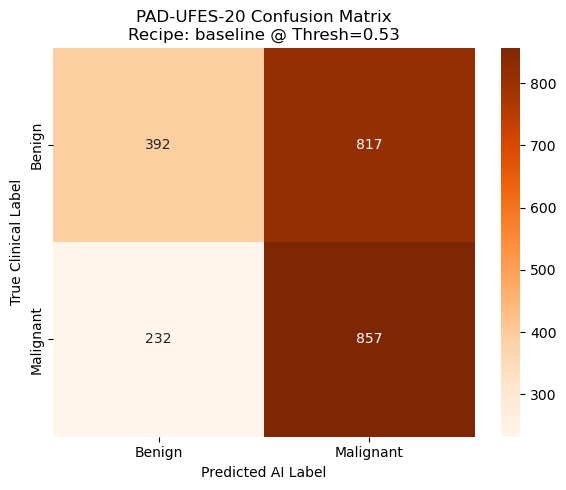

In [ ]:
print(f"\n" + "="*60)
print(f" EXTERNAL SMARTPHONE DATASET EVALUATION (PAD-UFES-20)")
print(f" Target Evaluation Recipe: {CHAMPION_RECIPE}")
print("="*60)

all_probs, all_y = [], []

# Set model to evaluation mode
model.eval()

with torch.no_grad():
    for xb, yb in phone_loader:
        xb = xb.to(device)
        
        logits = model(xb).squeeze(1)
        probs = 1 / (1 + torch.exp(-logits))
        
        all_probs.append(probs.cpu())
        all_y.append(yb.cpu())

y_true_phone = torch.cat(all_y).numpy()
y_score_phone = torch.cat(all_probs).numpy()

PHONE_THRESHOLD = FINAL_THRESHOLD
y_pred_phone = (y_score_phone >= PHONE_THRESHOLD).astype(int)

phone_report_dict = classification_report(
    y_true_phone, 
    y_pred_phone, 
    target_names=["benign", "malignant"], 
    output_dict=True
)

# Structure numerical row for storage
phone_metrics_row = [{
    "dataset": "PAD-UFES-20_Smartphone",
    "recipe_used": CHAMPION_RECIPE,
    "decision_threshold": PHONE_THRESHOLD,
    "accuracy": phone_report_dict["accuracy"],
    "malignant_precision": phone_report_dict["malignant"]["precision"],
    "malignant_recall": phone_report_dict["malignant"]["recall"],
    "malignant_f1_score": phone_report_dict["malignant"]["f1-score"],
    "benign_precision": phone_report_dict["benign"]["precision"],
    "benign_recall": phone_report_dict["benign"]["recall"]
}]

# Save metrics to a dedicated CSV file
phone_metrics_df = pd.DataFrame(phone_metrics_row)
phone_csv_path = folder_name + "/smartphone_evaluation_metrics.csv"
phone_metrics_df.to_csv(phone_csv_path, index=False)

print("\n--- PHONE DATASET PERFORMANCE REPORT ---")
print(classification_report(y_true_phone, y_pred_phone, target_names=["benign", "malignant"]))
print(f" Saved numerical metrics sheet to: {phone_csv_path}")


plt.figure(figsize=(6, 5))
cm_phone = confusion_matrix(y_true_phone, y_pred_phone)

sns.heatmap(cm_phone, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Benign', 'Malignant'], 
            yticklabels=['Benign', 'Malignant'])

plt.title(f"PAD-UFES-20 Confusion Matrix\nRecipe: {CHAMPION_RECIPE} @ Thresh={PHONE_THRESHOLD}")
plt.ylabel('True Clinical Label')
plt.xlabel('Predicted AI Label')
plt.tight_layout()

# Save final matrix image asset
# phone_img_path = folder_name + "/smartphone_confusion_matrix.png"
# plt.savefig(phone_img_path, dpi=300, bbox_inches='tight')
# print(f" Saved matrix visual layout to: {phone_img_path}")

plt.show()

In [ ]:
# Create a temporary dataframe to look at prediction confidence
analysis_df = pad_df.copy()
analysis_df['prob'] = y_score_phone  # raw probabilities from your test loop

# False Negatives: True label is 'malignant' (1), but model predicted benign (prob < 0.5)
# Sort by 'prob' ascending to get the absolute worst misses
false_negatives = analysis_df[(analysis_df['diagnostic'] == 'MEL') & (analysis_df['prob'] < 0.5)].sort_values(by='prob')

print(f"Total False Negatives found: {len(false_negatives)}")

# Let's copy the top 5 worst misses to a folder to inspect them
output_inspection_dir = "./worst_misses"
os.makedirs(output_inspection_dir, exist_ok=True)

for idx, row in false_negatives.head(5).iterrows():
    src = row['file_path']
    filename = os.path.basename(src)
    dst = os.path.join(output_inspection_dir, f"prob_{row['prob']:.3f}_{filename}")
    shutil.copy(src, dst)


Total False Negatives found: 2
Copied the 5 worst missed melanomas to ./worst_misses for visual inspection.


In [52]:
phone_mean, phone_std = estimate_norm(pad_df, do_vignette=False, do_hair=False, n=500)

print("Original Training Norm Stats: ", checkpoint["mean"], checkpoint["std"])
print("Smartphone Dataset Norm Stats:", phone_mean, phone_std)

Original Training Norm Stats:  [0.7820616364479065, 0.6049866676330566, 0.5777014493942261] [0.17382073402404785, 0.1868813931941986, 0.2065434604883194]
Smartphone Dataset Norm Stats: [0.6690585017204285, 0.5315722227096558, 0.4610045552253723] [0.1458669751882553, 0.14088520407676697, 0.1467820703983307]


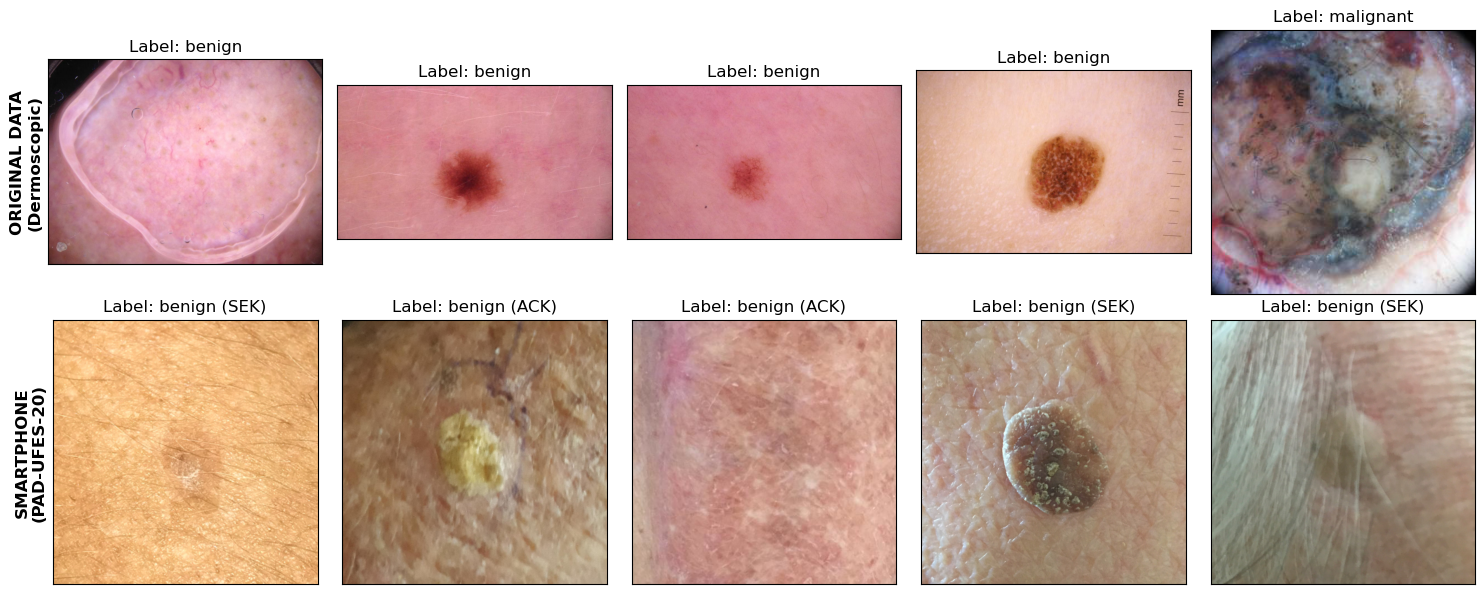

In [53]:
def compare_dataset_samples(original_df, smartphone_df, num_samples=5):
    """
    Plots random samples from both datasets side-by-side to inspect domain shift.
    
    Parameters:
    original_df (DataFrame): The dataset your model trained on (must have 'file_path' and 'label')
    smartphone_df (DataFrame): The new PAD-UFES smartphone dataset (must have 'file_path' and 'label')
    """
    # Sample a mix of benign and malignant rows from each dataset
    orig_samples = original_df.sample(n=num_samples, random_state=random.randint(1, 1000))
    phone_samples = smartphone_df.sample(n=num_samples, random_state=random.randint(1, 1000))
    
    # Create a 2-row grid: Row 1 = Original Data, Row 2 = Smartphone Data
    fig, axes = plt.subplots(2, num_samples, figsize=(3 * num_samples, 6))
    
    # --- Row 1: Plot Original Data ---
    for i, (_, row) in enumerate(orig_samples.iterrows()):
        ax = axes[0, i]
        try:
            img = Image.open(row['file_path']).convert('RGB')
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, "Error Loading", ha='center', va='center')
        
        # Add labels to keep track
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_ylabel("ORIGINAL DATA\n(Dermoscopic)", fontsize=12, fontweight='bold')
        ax.set_title(f"Label: {row['label']}")
        
    # --- Row 2: Plot Smartphone Data ---
    for i, (_, row) in enumerate(phone_samples.iterrows()):
        ax = axes[1, i]
        try:
            img = Image.open(row['file_path']).convert('RGB')
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, "Error Loading", ha='center', va='center')
            
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_ylabel("SMARTPHONE\n(PAD-UFES-20)", fontsize=12, fontweight='bold')
        
        # Pull the specific clinical shorthand abbreviation for deeper debugging context
        diagnostic_type = row.get('diagnostic', 'Unknown')
        ax.set_title(f"Label: {row['label']} ({diagnostic_type})")
        
    plt.tight_layout()
    plt.show()

# --- How to run it ---
# Pass your training dataframe and your prepared smartphone dataframe
compare_dataset_samples(train_df, pad_df, num_samples=5)

## 5.1 Histogram matchin

In [59]:
import numpy as np
from PIL import Image
from skimage.exposure import match_histograms

# 1. Grab a solid reference path from your clean training data
# (Pick an index manually or take a random clean sample once)
REF_SAMPLE_PATH = train_df.iloc[0]['file_path'] 

# 2. Load it once globally as a standard NumPy array for speed
# match_histograms requires a raw numpy array image
REFERENCE_IMAGE_NUMPY = np.array(Image.open(REF_SAMPLE_PATH).convert('RGB'))

# Keep your original toggles, and add the matching flag
DO_VIGNETTE = False
DO_HAIR = False
DO_HIST_MATCH = True  # <-- Toggle this on to activate color warping!

def new_preprocess_pil(img_path, do_vignette=DO_VIGNETTE, do_hair=DO_HAIR, do_hist_match=DO_HIST_MATCH):
    # 1. Load the target image
    img = Image.open(img_path).convert('RGB')
    
    # 2. Apply your existing structural hair/vignette removals
    if do_vignette and has_vignette_border(img_path):
        img = crop_to_detected_circle(img_path)
    if do_hair:
        img = remove_hair(img)
        
    # 3. New Step: Apply Histogram Color Correction
    if do_hist_match:
        # Convert PIL to a raw NumPy array
        img_np = np.array(img)
        
        # Warp the smartphone colors to mirror your Golden Reference image
        # channel_axis=-1 tells skimage that the color dimension is the last index (RGB)
        matched_np = match_histograms(img_np, REFERENCE_IMAGE_NUMPY, channel_axis=-1)
        
        # Convert back to PIL Image so it passes cleanly to T.Compose transforms
        img = Image.fromarray(matched_np.astype('uint8'))
        
    return img
    
class NewMelanomaDataset(Dataset):
    def __init__(self, df, transform, use_hair, use_vignette, use_hist_match=True):
        self.paths = df['file_path'].tolist()
        self.labels = (df['label'] == 'malignant').astype('int64').tolist() #1 malignant, 0 benign
        self.transform = transform
        self.use_hair = use_hair
        self.use_vignette = use_vignette
        self.use_hist_match = use_hist_match  # <-- Store flag

    def __len__(self): 
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        
        # Pass the flag into your updated preprocess function
        img = new_preprocess_pil(
            p, 
            do_vignette=self.use_vignette, 
            do_hair=self.use_hair, 
            do_hist_match=self.use_hist_match
        )
        
        img = self.transform(img)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, y

In [60]:
phone_dataset = NewMelanomaDataset(
    df=pad_df, 
    transform=val_tfms, # Keep using your original training mean/std!
    use_hair=False, 
    use_vignette=False,
    use_hist_match=True # <-- Activates color correction
)

phone_loader = DataLoader(phone_dataset, batch_size=64, shuffle=False, num_workers=6)


 SMARTPHONE DATASET EVALUATION (PAD-UFES-20)
 Target Evaluation Recipe: baseline including histogram matching

--- PHONE DATASET PERFORMANCE REPORT ---
              precision    recall  f1-score   support

      benign       0.62      0.52      0.57      1209
   malignant       0.55      0.65      0.60      1089

    accuracy                           0.58      2298
   macro avg       0.59      0.59      0.58      2298
weighted avg       0.59      0.58      0.58      2298

 Saved numerical metrics sheet to: ../models/splits_2026-05-28_84754/smartphone_evaluation_metrics.csv


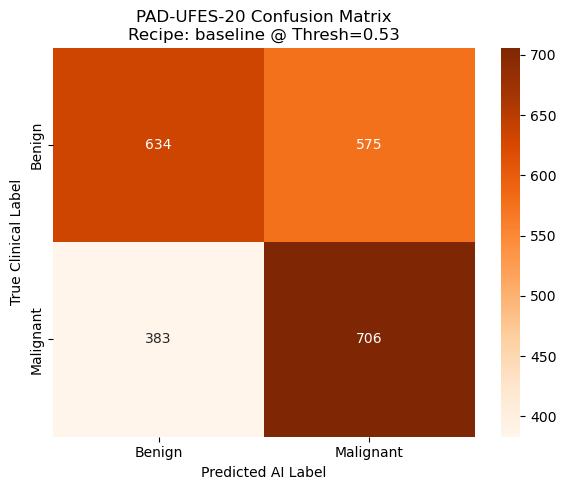

In [ ]:
print(f"\n" + "="*60)
print(f" SMARTPHONE DATASET EVALUATION (PAD-UFES-20)")
print(f" Target Evaluation Recipe: {CHAMPION_RECIPE} including histogram matching")
print("="*60)

all_probs, all_y = [], []

model.eval()

with torch.no_grad():
    for xb, yb in phone_loader:
        xb = xb.to(device)
        logits = model(xb).squeeze(1)
        probs = 1 / (1 + torch.exp(-logits))
        
        all_probs.append(probs.cpu())
        all_y.append(yb.cpu())

# Flatten prediction arrays
y_true_phone = torch.cat(all_y).numpy()
y_score_phone = torch.cat(all_probs).numpy()

PHONE_THRESHOLD = FINAL_THRESHOLD
y_pred_phone = (y_score_phone >= PHONE_THRESHOLD).astype(int)

phone_report_dict = classification_report(
    y_true_phone, 
    y_pred_phone, 
    target_names=["benign", "malignant"], 
    output_dict=True
)

phone_metrics_row = [{
    "dataset": "PAD-UFES-20_Smartphone",
    "recipe_used": CHAMPION_RECIPE,
    "decision_threshold": PHONE_THRESHOLD,
    "accuracy": phone_report_dict["accuracy"],
    "malignant_precision": phone_report_dict["malignant"]["precision"],
    "malignant_recall": phone_report_dict["malignant"]["recall"],
    "malignant_f1_score": phone_report_dict["malignant"]["f1-score"],
    "benign_precision": phone_report_dict["benign"]["precision"],
    "benign_recall": phone_report_dict["benign"]["recall"]
}]

# Save metrics to a dedicated CSV file
# phone_metrics_df = pd.DataFrame(phone_metrics_row)
# phone_csv_path = folder_name + "/smartphone_evaluation_metrics.csv"
# phone_metrics_df.to_csv(phone_csv_path, index=False)

print("\n--- PHONE DATASET PERFORMANCE REPORT ---")
print(classification_report(y_true_phone, y_pred_phone, target_names=["benign", "malignant"]))
# print(f" Saved numerical metrics sheet to: {phone_csv_path}")


plt.figure(figsize=(6, 5))
cm_phone = confusion_matrix(y_true_phone, y_pred_phone)

sns.heatmap(cm_phone, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Benign', 'Malignant'], 
            yticklabels=['Benign', 'Malignant'])

plt.title(f"PAD-UFES-20 Confusion Matrix\nRecipe: {CHAMPION_RECIPE} @ Thresh={PHONE_THRESHOLD}")
plt.ylabel('True Clinical Label')
plt.xlabel('Predicted AI Label')
plt.tight_layout()

# Save final matrix image asset
# phone_img_path = folder_name + "/smartphone_confusion_matrix.png"
# plt.savefig(phone_img_path, dpi=300, bbox_inches='tight')
# print(f" Saved matrix visual layout to: {phone_img_path}")

plt.show()

# Future testS
Heavy Color Augmentation (For Future Re-training): force it to be color-blind. step up  T.ColorJitter in  training pipeline or use severe brightness/contrast randomizations so the network learns shapes instead of relying so heavily on absolute RGB values.

Histogram Matching / Contrast Stretching: Before passing the smartphone image to the model, use a preprocessing tool (like skimage.exposure.match_histograms) to artificially warp the color profile of the smartphone photo to match the palette of your training images.